<a href="https://colab.research.google.com/github/Ishan-malinda/Machine-Learning-Algorithm-for-Bank-Loan-System-Prediction/blob/main/Ensemble_Learner_and_Decision_Tree_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Notebook 3 — Ensemble Learner and Decision Tree Regression  
Author: W.F. ISHAN MALINDA SOVIS   

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Import pandas library for data loading and manipulation

In [ ]:
# Import pandas library for data loading and manipulation
import pandas as pd

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Control pandas display settings to prevent data truncation

In [ ]:
# Set maximum rows pandas will display to 500
pd.set_option('display.max_rows', 500)
# Set maximum columns pandas will display to 500
pd.set_option('display.max_columns', 500)
# Set display width to 150 to prevent line wrapping
pd.set_option('display.width', 150)

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Load the prepared classification dataset saved from Notebook 1 for ensemble modelling

In [ ]:
# Load the prepared classification dataset from Notebook 1
data = pd.read_csv('/content/drive/MyDrive/ML & DM/CW/loan_classification_prepared.csv')
# Display first 15 rows to confirm dataset loaded correctly
data.head(15)

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,0.3125,0.093788,3,0.020000,1,1.000000,0.558824,0.228916,0,0.321429,0
1,0.3125,0.045258,0,0.020000,2,1.000000,0.676471,0.469880,0,0.428571,0
2,0.3125,0.066887,0,0.060000,5,0.855072,0.529412,0.277108,0,0.392857,0
3,0.3125,0.076907,0,0.060000,0,0.710145,0.647059,0.204819,0,0.321429,0
4,0.3125,0.067412,0,0.020000,2,0.710145,0.794118,0.265060,0,0.535714,0
5,0.3125,0.039983,0,0.013333,0,0.710145,0.617647,0.373494,0,0.321429,0
6,0.3125,0.039983,0,0.060000,5,0.710145,0.852941,0.361446,0,0.535714,0
7,0.3125,0.029433,2,0.033333,5,0.710145,0.647059,0.506024,1,0.357143,0
8,0.3125,0.042621,0,0.020000,2,0.710145,0.676471,0.349398,0,0.500000,0
9,0.3125,0.034706,2,0.126667,1,0.710145,0.852941,0.433735,0,0.428571,0


Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Check data types and non-null counts to confirm dataset is clean and ready for modelling

In [ ]:
# Display data types and non-null counts to verify dataset is clean
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58636 entries, 0 to 58635
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      58636 non-null  float64
 1   income                   58636 non-null  float64
 2   home_ownership           58636 non-null  int64  
 3   emplyment_length         58636 non-null  float64
 4   loan_intent              58636 non-null  int64  
 5   loan_amount              58636 non-null  float64
 6   loan_interest_rate       58636 non-null  float64
 7   loan_income_ratio        58636 non-null  float64
 8   payment_default_on_file  58636 non-null  int64  
 9   credit_history_length    58636 non-null  float64
 10  loan_approval_status     58636 non-null  int64  
dtypes: float64(7), int64(4)
memory usage: 4.9 MB


Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Declare input features X and target output variable y for ensemble classification modelling

In [ ]:
# Define the list of input feature column names
feature_cols = ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent',
                'loan_amount', 'loan_interest_rate', 'loan_income_ratio',
                'payment_default_on_file', 'credit_history_length']
# Assign input features to X
X = data[feature_cols]
# Assign target variable loan_approval_status to y
y = data['loan_approval_status']
# Display shape of X to confirm correct features and instances
print("X shape:", X.shape)
# Display shape of y to confirm target variable
print("y shape:", y.shape)

X shape: (58636, 10)
y shape: (58636,)


Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Import train_test_split to split data into training and test subsets

In [ ]:
# Import train_test_split from sklearn model selection
from sklearn.model_selection import train_test_split

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Split dataset into 80% training and 20% test subsets using same conditions as Notebook 2 to ensure consistent and comparable results

In [ ]:
# Split data into 80% training and 20% test subsets
# random_state=42 ensures identical split to Notebook 2 for consistency
# stratify=y preserves the class ratio of Approved vs Rejected in both subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42,
                                                     stratify=y)
# Confirm training subset size
print("X_train shape:", X_train.shape)
# Confirm test subset size
print("X_test shape:", X_test.shape)

X_train shape: (46908, 10)
X_test shape: (11728, 10)


Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Import and build the Logistic Regression base learner — chosen as first base learner due to its high Recall score of 0.98 for the Rejected class in Notebook 2

In [ ]:
# Import Logistic Regression from sklearn linear model module
from sklearn.linear_model import LogisticRegression
# Create Logistic Regression model instance
lr_model = LogisticRegression()
# Train Logistic Regression model on the training subset
lr_model.fit(X_train, y_train)
# Predict loan approval status on the test subset
lr_pred = lr_model.predict(X_test)

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Evaluate Logistic Regression base learner with confusion matrix to assess performance before ensemble combination

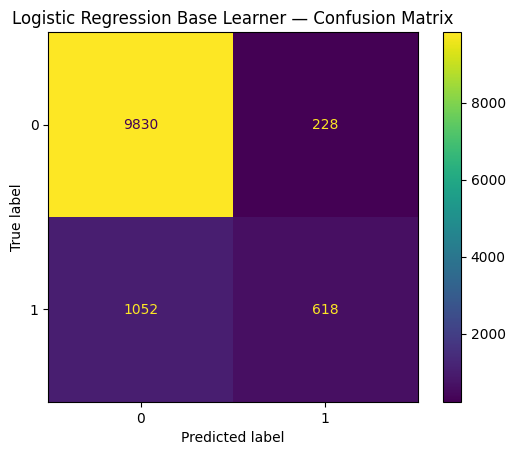

In [ ]:
# Import confusion matrix and display tools
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Calculate confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred, labels=lr_model.classes_)
# Create display object for LR confusion matrix
disp_lr = ConfusionMatrixDisplay(cm_lr, display_labels=lr_model.classes_)
# Plot and display the confusion matrix
disp_lr.plot()
# Add title to identify this matrix
plt.title("Logistic Regression Base Learner — Confusion Matrix")
plt.show()

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Generate classification report for Logistic Regression base learner showing all evaluation metrics  

In [ ]:
# Import classification report from sklearn metrics
from sklearn.metrics import classification_report
# Generate and print classification report for LR base learner
print("Logistic Regression Base Learner — Classification Report")
print(classification_report(y_test, lr_pred))

Logistic Regression Base Learner — Classification Report
              precision    recall  f1-score   support

           0       0.90      0.98      0.94     10058
           1       0.73      0.37      0.49      1670

    accuracy                           0.89     11728
   macro avg       0.82      0.67      0.72     11728
weighted avg       0.88      0.89      0.88     11728



Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Plot AUC-ROC curve for Logistic Regression base learner  

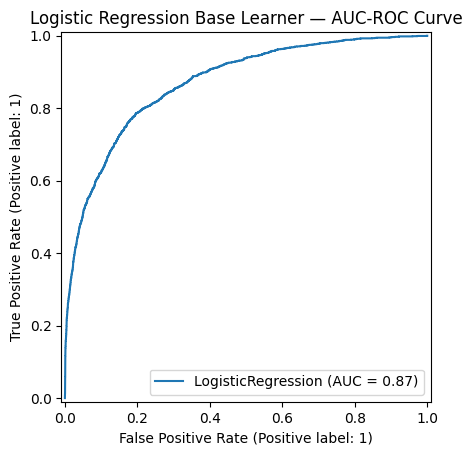

In [ ]:
# Import RocCurveDisplay for AUC-ROC plotting
from sklearn.metrics import RocCurveDisplay
# Plot AUC-ROC curve for Logistic Regression base learner
lr_roc = RocCurveDisplay.from_estimator(lr_model, X_test, y_test)
# Add title to identify this curve
plt.title("Logistic Regression Base Learner — AUC-ROC Curve")
plt.show()

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Import and build the Naive Bayes base learner — chosen as second base learner due to its high Precision score of 0.93 for the Rejected class in Notebook 2, complementing LR's high Recall

In [ ]:
# Import GaussianNB from sklearn naive bayes module
from sklearn.naive_bayes import GaussianNB
# Create Naive Bayes model instance
nb_model = GaussianNB()
# Train Naive Bayes model on the training subset
nb_model.fit(X_train, y_train)
# Predict loan approval status on the test subset
nb_pred = nb_model.predict(X_test)

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Evaluate Naive Bayes base learner with confusion matrix  

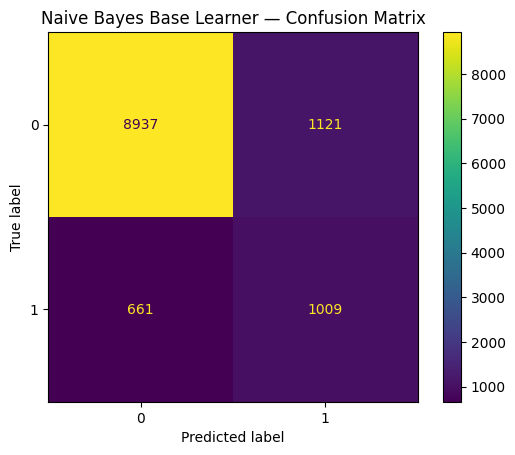

In [ ]:
# Calculate confusion matrix for Naive Bayes base learner
cm_nb = confusion_matrix(y_test, nb_pred, labels=nb_model.classes_)
# Create display object for NB confusion matrix
disp_nb = ConfusionMatrixDisplay(cm_nb, display_labels=nb_model.classes_)
# Plot and display the NB confusion matrix
disp_nb.plot()
# Add title to identify this matrix
plt.title("Naive Bayes Base Learner — Confusion Matrix")
plt.show()

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Generate classification report for Naive Bayes base learner  

In [ ]:
# Generate and print classification report for NB base learner
print("Naive Bayes Base Learner — Classification Report")
print(classification_report(y_test, nb_pred))

Naive Bayes Base Learner — Classification Report
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     10058
           1       0.47      0.60      0.53      1670

    accuracy                           0.85     11728
   macro avg       0.70      0.75      0.72     11728
weighted avg       0.87      0.85      0.86     11728



Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Plot AUC-ROC curve for Naive Bayes base learner  

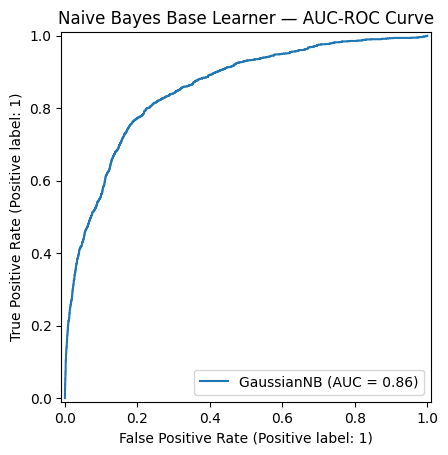

In [ ]:
# Plot AUC-ROC curve for Naive Bayes base learner
nb_roc = RocCurveDisplay.from_estimator(nb_model, X_test, y_test)
# Add title to identify this curve
plt.title("Naive Bayes Base Learner — AUC-ROC Curve")
plt.show()

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Import VotingClassifier from sklearn ensemble module to combine base learners into a single ensemble model

In [ ]:
# Import VotingClassifier for building the ensemble model
from sklearn.ensemble import VotingClassifier

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Declare the voting ensemble combining Logistic Regression and Naive Bayes base learners using soft voting — soft voting uses predicted class probabilities from each base learner to make the final combined decision rather than majority vote  

In [ ]:
# Declare the voting ensemble with LR and NB as base learners
# voting='soft' uses class probabilities from each model for final decision
ensemble_model = VotingClassifier(
    estimators=[
        ('lr', lr_model),
        ('nb', nb_model)
    ],
    voting='soft'
)
# Train the ensemble model on the training subset
ensemble_model.fit(X_train, y_train)
# Predict loan approval status using the ensemble on the test subset
ensemble_pred = ensemble_model.predict(X_test)

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Evaluate the ensemble model with confusion matrix to compare against individual base learners  

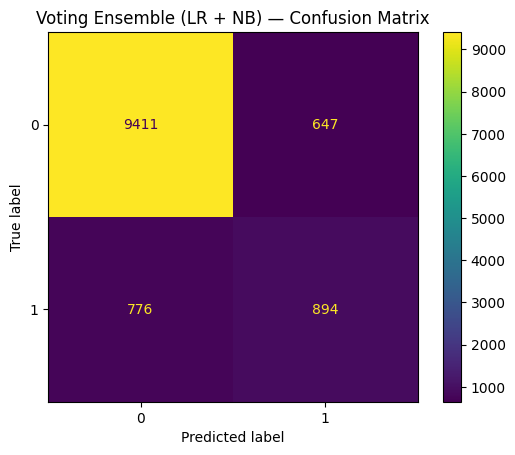

In [ ]:
# Calculate confusion matrix for the ensemble model
cm_ensemble = confusion_matrix(y_test, ensemble_pred, labels=ensemble_model.classes_)
# Create display object for ensemble confusion matrix
disp_ensemble = ConfusionMatrixDisplay(cm_ensemble, display_labels=ensemble_model.classes_)
# Plot and display the ensemble confusion matrix
disp_ensemble.plot()
# Add title to identify this as the ensemble result
plt.title("Voting Ensemble (LR + NB) — Confusion Matrix")
plt.show()

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Generate classification report for the ensemble model showing all evaluation metrics  

In [ ]:
# Generate and print classification report for the ensemble model
print("Voting Ensemble (LR + NB) — Classification Report")
print(classification_report(y_test, ensemble_pred))

Voting Ensemble (LR + NB) — Classification Report
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     10058
           1       0.58      0.54      0.56      1670

    accuracy                           0.88     11728
   macro avg       0.75      0.74      0.74     11728
weighted avg       0.87      0.88      0.88     11728



Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Plot AUC-ROC curve for the ensemble model to compare discriminative ability against individual base learners  

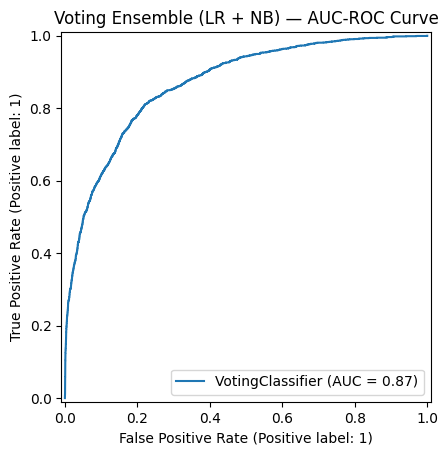

In [ ]:
# Plot AUC-ROC curve for the voting ensemble model
ensemble_roc = RocCurveDisplay.from_estimator(ensemble_model, X_test, y_test)
# Add title to identify this as the ensemble curve
plt.title("Voting Ensemble (LR + NB) — AUC-ROC Curve")
plt.show()

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Load the prepared regression dataset saved from Notebook 1 — contains approved clients only with Maximum Loan Amount as the target variable  

In [ ]:
# Load the prepared regression dataset from Notebook 1
data_reg = pd.read_csv('/content/drive/MyDrive/ML & DM/CW/loan_regression_prepared.csv')
# Display dimensions of the regression dataset
print("Regression dataset shape:", data_reg.shape)
# Display all feature names in the regression dataset
print("Features:", list(data_reg.columns))
# Display first 5 rows to confirm it loaded correctly
data_reg.head()

Regression dataset shape: (8349, 11)
Features: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'max_allowed_loan']


,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,max_allowed_loan
0,0.000000,0.302421,0,0.01626,0,0.683824,0.555556,0.219512,0,0.071429,0
1,0.000000,0.222437,3,0.01626,1,0.801471,0.500000,0.317073,0,0.071429,0
2,0.000000,0.127254,3,0.00813,4,0.464706,0.388889,0.341463,0,0.000000,0
3,0.016667,0.052550,3,0.04065,2,0.161765,0.500000,0.256098,0,0.071429,0
4,0.016667,0.055126,3,0.04065,1,0.264706,0.333333,0.378049,0,0.000000,0


Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Declare input features X_reg and target output y_reg for regression modelling of Maximum Loan Amount

In [ ]:
# Define target variable — loan_amount
y_reg = data_reg['loan_amount']
# Define input features for regression by dropping the target variable and the problematic 'max_allowed_loan'
X_reg = data_reg.drop(['loan_amount', 'max_allowed_loan'], axis=1)
# Display shape of regression features
print("X_reg shape:", X_reg.shape)
# Display shape of regression target
print("y_reg shape:", y_reg.shape)

X_reg shape: (8349, 9)
y_reg shape: (8349,)


Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Split regression dataset into 80% training and 20% test subsets using random_state=42 for reproducibility

In [ ]:
# Split regression dataset into 80% training and 20% test subsets
# random_state=42 ensures reproducible split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)
# Confirm training subset size
print("X_train_reg shape:", X_train_reg.shape)
# Confirm test subset size
print("X_test_reg shape:", X_test_reg.shape)

X_train_reg shape: (6679, 9)
X_test_reg shape: (1670, 9)


Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Import DecisionTreeRegressor from sklearn to build regression models for predicting Maximum Loan Amount

In [ ]:
# Import DecisionTreeRegressor from sklearn tree module
from sklearn.tree import DecisionTreeRegressor

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Build DT-1 — a fully grown decision tree regressor with no pruning constraints. random_state=42 ensures reproducible tree structure  

In [ ]:
# Build DT-1 — fully grown decision tree with no pruning restrictions
dt1 = DecisionTreeRegressor(random_state=42)
# Train DT-1 on the regression training subset
dt1.fit(X_train_reg, y_train_reg)
# Predict Maximum Loan Amount on the test subset using DT-1
y_pred_dt1 = dt1.predict(X_test_reg)
# Confirm DT-1 was built successfully
print("DT-1 fully grown tree built successfully")
print("Number of leaves:", dt1.get_n_leaves())
print("Tree depth:", dt1.get_depth())

DT-1 fully grown tree built successfully
Number of leaves: 2507
Tree depth: 23


Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Build DT-2 — a pruned decision tree regressor limited to exactly four levels using max_depth=4. This is pre-pruning which stops the tree growing beyond four levels to prevent overfitting  

In [ ]:
# Build DT-2 — pruned decision tree restricted to maximum depth of 4 levels
dt2 = DecisionTreeRegressor(max_depth=4, random_state=42)
# Train DT-2 on the regression training subset
dt2.fit(X_train_reg, y_train_reg)
# Predict Maximum Loan Amount on the test subset using DT-2
y_pred_dt2 = dt2.predict(X_test_reg)
# Confirm DT-2 was built successfully
print("DT-2 pruned tree (max_depth=4) built successfully")
print("Number of leaves:", dt2.get_n_leaves())
print("Tree depth:", dt2.get_depth())

DT-2 pruned tree (max_depth=4) built successfully
Number of leaves: 16
Tree depth: 4


Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Import matplotlib and plot_tree to visualise both DT-1 and DT-2 decision tree structures

In [ ]:
# Import plot_tree for decision tree visualisation
from sklearn.tree import plot_tree
# Import matplotlib for figure control
import matplotlib.pyplot as plt

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Visualise DT-2 pruned tree (max_depth=4) at high resolution — pruned tree is visualised first as it is readable and interpretable due to its limited depth of four levels  

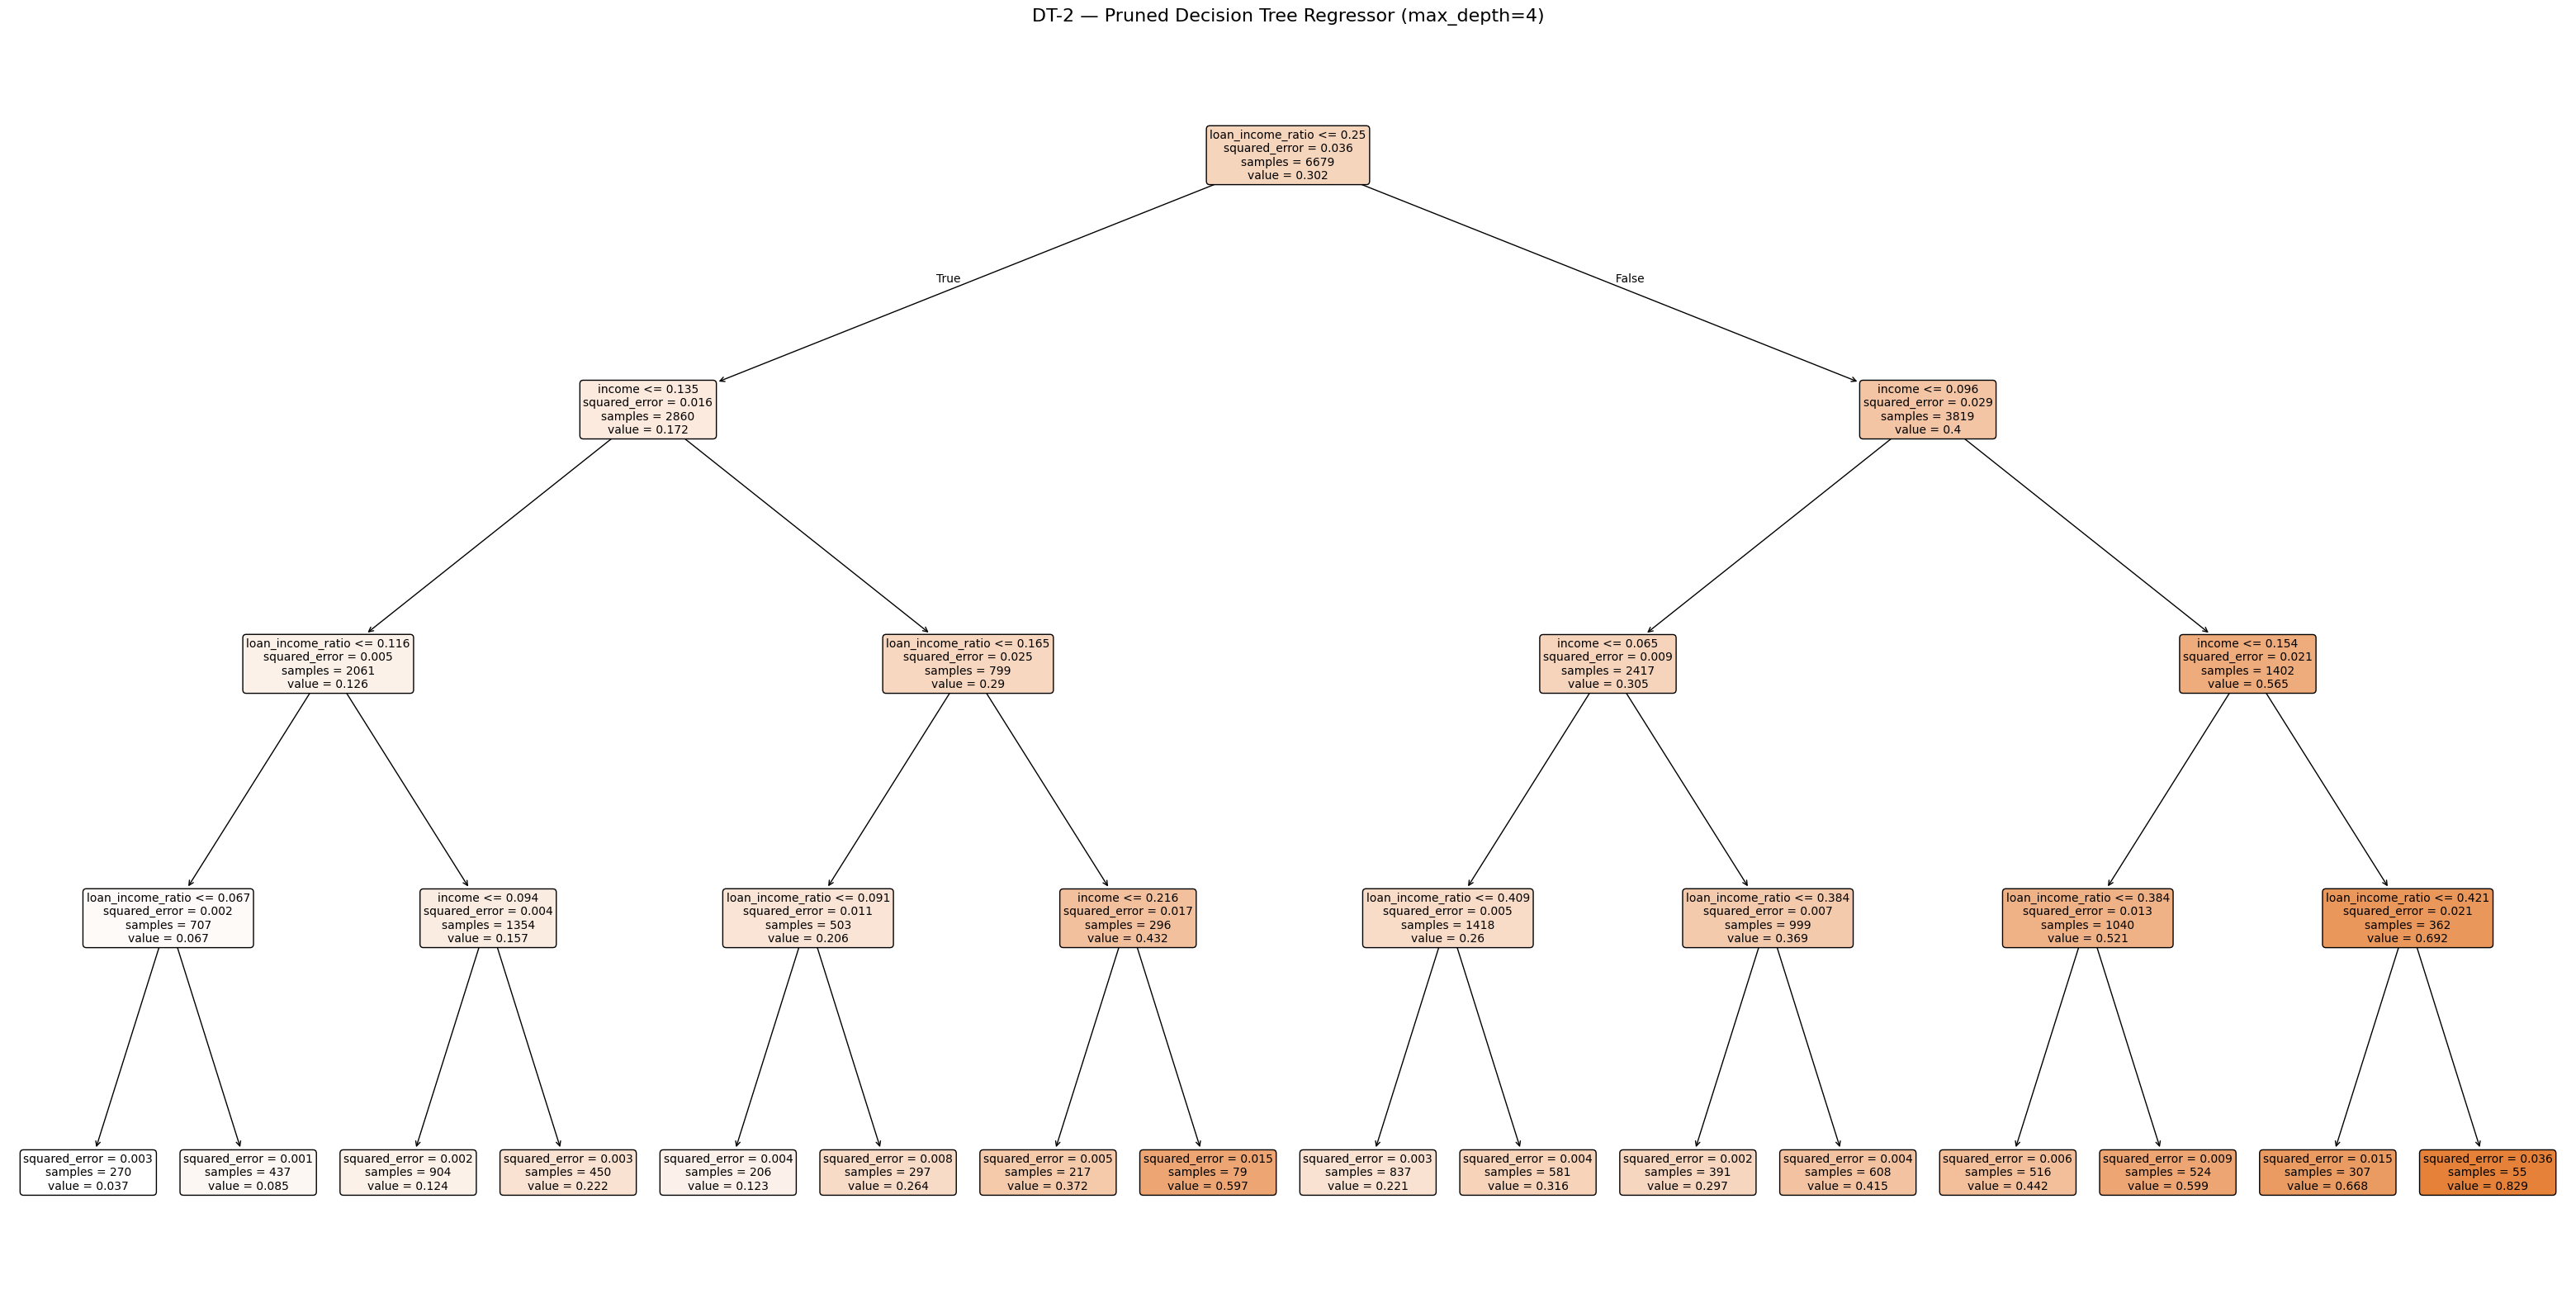

In [ ]:
# Set figure size large enough for clear high resolution visualisation of DT-2
plt.figure(figsize=(40, 20))
# Plot DT-2 pruned tree with feature names and filled colour nodes
plot_tree(dt2,
          feature_names=X_reg.columns,
          filled=True,
          rounded=True,
          fontsize=10)
# Add title to identify this as DT-2
plt.title("DT-2 — Pruned Decision Tree Regressor (max_depth=4)", fontsize=16)
# Display the tree
plt.show()

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Visualise DT-1 fully grown tree at high resolution — note this tree will be very large due to no depth restriction  

In [ ]:
# Set figure size very large to accommodate the fully grown DT-1 tree
plt.figure(figsize=(80, 40))
# Plot DT-1 fully grown tree with feature names and filled colour nodes
plot_tree(dt1,
          feature_names=X_reg.columns,
          filled=True,
          rounded=True,
          fontsize=6)
# Add title to identify this as DT-1
plt.title("DT-1 — Fully Grown Decision Tree Regressor (No Pruning)", fontsize=16)
# Display the tree
plt.show()

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Instantiate MinMaxScaler

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Define the numeric columns that need scaling for the client data.
numeric_cols = ['age', 'income', 'emplyment_length', 'loan_interest_rate', 'loan_income_ratio', 'credit_history_length']

# Instantiate MinMaxScaler.
scaler2 = MinMaxScaler()
scaler2.fit(X_train_reg[numeric_cols])

MinMaxScaler()

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Import regression evaluation metrics — MSE measures average squared error penalising large errors heavily, MAE measures average absolute error, R2 measures overall variance explained by the model

In [ ]:
# Import regression evaluation metrics from sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Evaluate DT-1 fully grown tree on test subset using MSE, MAE and R2 metrics  

In [ ]:
# Calculate MSE for DT-1 — penalises large prediction errors heavily
print("DT-1 MSE:", mean_squared_error(y_test_reg, y_pred_dt1))
# Calculate MAE for DT-1 — average absolute prediction error
print("DT-1 MAE:", mean_absolute_error(y_test_reg, y_pred_dt1))
# Calculate R2 for DT-1 — proportion of variance explained by the model
print("DT-1 R2:", r2_score(y_test_reg, y_pred_dt1))

DT-1 MSE: 0.0017687375163168476
DT-1 MAE: 0.012574498062698171
DT-1 R2: 0.9496259136208941


Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Evaluate DT-2 pruned tree on test subset using MSE, MAE and R2 metrics for comparison with DT-1  

In [ ]:
# Calculate MSE for DT-2 — penalises large prediction errors heavily
print("DT-2 MSE:", mean_squared_error(y_test_reg, y_pred_dt2))
# Calculate MAE for DT-2 — average absolute prediction error
print("DT-2 MAE:", mean_absolute_error(y_test_reg, y_pred_dt2))
# Calculate R2 for DT-2 — proportion of variance explained by the model
print("DT-2 R2:", r2_score(y_test_reg, y_pred_dt2))

DT-2 MSE: 0.004933988033312446
DT-2 MAE: 0.04905066704027479
DT-2 R2: 0.8594787880673684


Session name: Ensemble Learner and Decision Tree Regression  
Purpose: Predict the Maximum Loan Amount for Client 60256 using the best performing decision tree model based on MSE and R2 evaluation scores  

In [ ]:
# Define Client 60256 attributes based on the coursework specification
# Female=0 (encoded), Age=56, Income=57000, Home=RENT encoded value
# Employment=15, Intent=MEDICAL encoded value,
# InterestRate=23, LTI=0.10, DefaultOnFile=N=0, CreditHistory=35
client_60256 = pd.DataFrame({
    'age': [56],
    'income': [57000],
    'home_ownership': [3],
    'emplyment_length': [15],
    'loan_intent': [3],
    'loan_interest_rate': [23],
    'loan_income_ratio': [0.10],
    'payment_default_on_file': [0],
    'credit_history_length': [35]
})

# Scale the numeric features of client_60256 using the fitted scaler
client_60256_scaled = client_60256.copy()
client_60256_scaled[numeric_cols] = scaler2.transform(client_60256[numeric_cols])

# Get the original min and max values of 'loan_amount' for inverse scaling.
# These values are inferred from the `y_regression` variable in the kernel state
# (which represents the unscaled 'loan_amount' before being saved to CSV as scaled).
original_loan_amount_min = 500
original_loan_amount_max = 35000

# Create a dummy scaler to inverse transform the predicted loan amount.
# This scaler is conceptually fitted on the original range [original_loan_amount_min, original_loan_amount_max]
# and scales to [0, 1].
loan_amount_scaler = MinMaxScaler()
loan_amount_scaler.fit([[original_loan_amount_min], [original_loan_amount_max]])

# Predict Maximum Loan Amount for Client 60256 using best model
# Replace dt2 with dt1 below if DT-1 is your best model based on evaluation
predicted_loan_scaled = dt1.predict(client_60256_scaled)

# Inverse transform the predicted loan amount
predicted_loan_unscaled = loan_amount_scaler.inverse_transform(predicted_loan_scaled.reshape(-1, 1))[0][0]

# Display the predicted Maximum Loan Amount (unscaled)
print("Predicted Maximum Loan Amount for Client 60256: £", round(predicted_loan_unscaled, 2))

Predicted Maximum Loan Amount for Client 60256: £ 24852.94
